### imports

In [1]:
import os, sys
os.chdir("/home/kirschkobold/LIFEsim")
sys.path.insert(0, os.getcwd())

In [2]:
import astropy.units as u
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import lifesim
from spectres import spectres

In [3]:
import lifesim
print(lifesim.__file__)

/home/kirschkobold/LIFEsim/lifesim/__init__.py


In [4]:
print(os.getcwd())
print(os.path.abspath(""))

/home/kirschkobold/LIFEsim/lifesim/gui
/home/kirschkobold/LIFEsim/lifesim/gui


In [5]:
import os

for root, dirs, files in os.walk("/home/kirschkobold/LIFEsim", topdown=True):
    if "lifesim" in dirs:
        print("Found lifesim at:", os.path.join(root, "lifesim"))
        break

Found lifesim at: /home/kirschkobold/LIFEsim/lifesim


In [6]:
import sys
for p in sys.path:
    print(p)

/home/kirschkobold/LIFEsim
/usr/lib/python38.zip
/usr/lib/python3.8
/usr/lib/python3.8/lib-dynload

/home/kirschkobold/lifesim-38/lib/python3.8/site-packages


In [7]:
import os
print(os.path.exists("/home/kirschkobold/LIFEsim/lifesim"))
print(os.path.exists("/home/kirschkobold/LIFEsim/lifesim/__init__.py"))

True
True


### Import spectrum and convert to LIFEsim units

In [8]:
data=pd.read_csv('/home/kirschkobold/LIFEsim/kira_testing/Earth_PRTunits_10pc.txt',header=None, sep='\s+')

lam_PRT=data[0].values*u.micron
f_PRT=data[1].values*u.erg/u.cm**2/u.s/u.Hz
f_lifesim = f_PRT.to(u.photon / u.m**2 / u.s / u.micron,\
                      equivalencies=u.spectral_density(lam_PRT))

f_lifesim = f_lifesim.to(u.photon / u.s / u.meter**3)
lam_lifesim = lam_PRT.to(u.meter)

### Set up LIFEsim

In [10]:
bus = lifesim.Bus()

bus.data.options.set_scenario('baseline')

instrument = lifesim.Instrument(name='inst')
bus.add_module(instrument)

transm = lifesim.TransmissionMap(name='transm')
bus.add_module(transm)

exo = lifesim.PhotonNoiseExozodi(name='exo')
bus.add_module(exo)
local = lifesim.PhotonNoiseLocalzodi(name='local')
bus.add_module(local)
star = lifesim.PhotonNoiseStar(name='star')
bus.add_module(star)
mirror = lifesim.PhotonNoiseThermal(name='mirror')
bus.add_module(mirror)
darkcurrent = lifesim.ElectronNoiseDarkCurrent(name='darkcurrent')
bus.add_module(darkcurrent)


# connect all modules
bus.connect(('inst', 'transm'))
bus.connect(('inst', 'exo'))
bus.connect(('inst', 'local'))
bus.connect(('inst', 'star'))
bus.connect(('inst', 'mirror'))
bus.connect(('inst', 'darkcurrent'))


bus.connect(('star', 'transm'))

instrument.apply_options()

### Run spectrum through LIFEsim

In [11]:
integration_time = 55*60*60

spectrum, flux_planet, noise = instrument.get_spectrum(temp_s=5778,  # star temperature in K
                                                       radius_s=1,  # star radius in solar radii
                                                       distance_s=10,  # distance to system in pc
                                                       lat_s=0.78,  # ecliptic latitude of observation in rad
                                                       z=3,  # zodi level
                                                       angsep=0.1,  # angular separation of planet in arcsec
                                                       flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                       safe_mode=True,
                                                      integration_time=integration_time)

In [12]:
prefactor = (integration_time 
             * bus.data.inst['eff_tot'] 
             * bus.data.inst['telescope_area'] 
             * bus.data.inst['wl_bin_widths'])

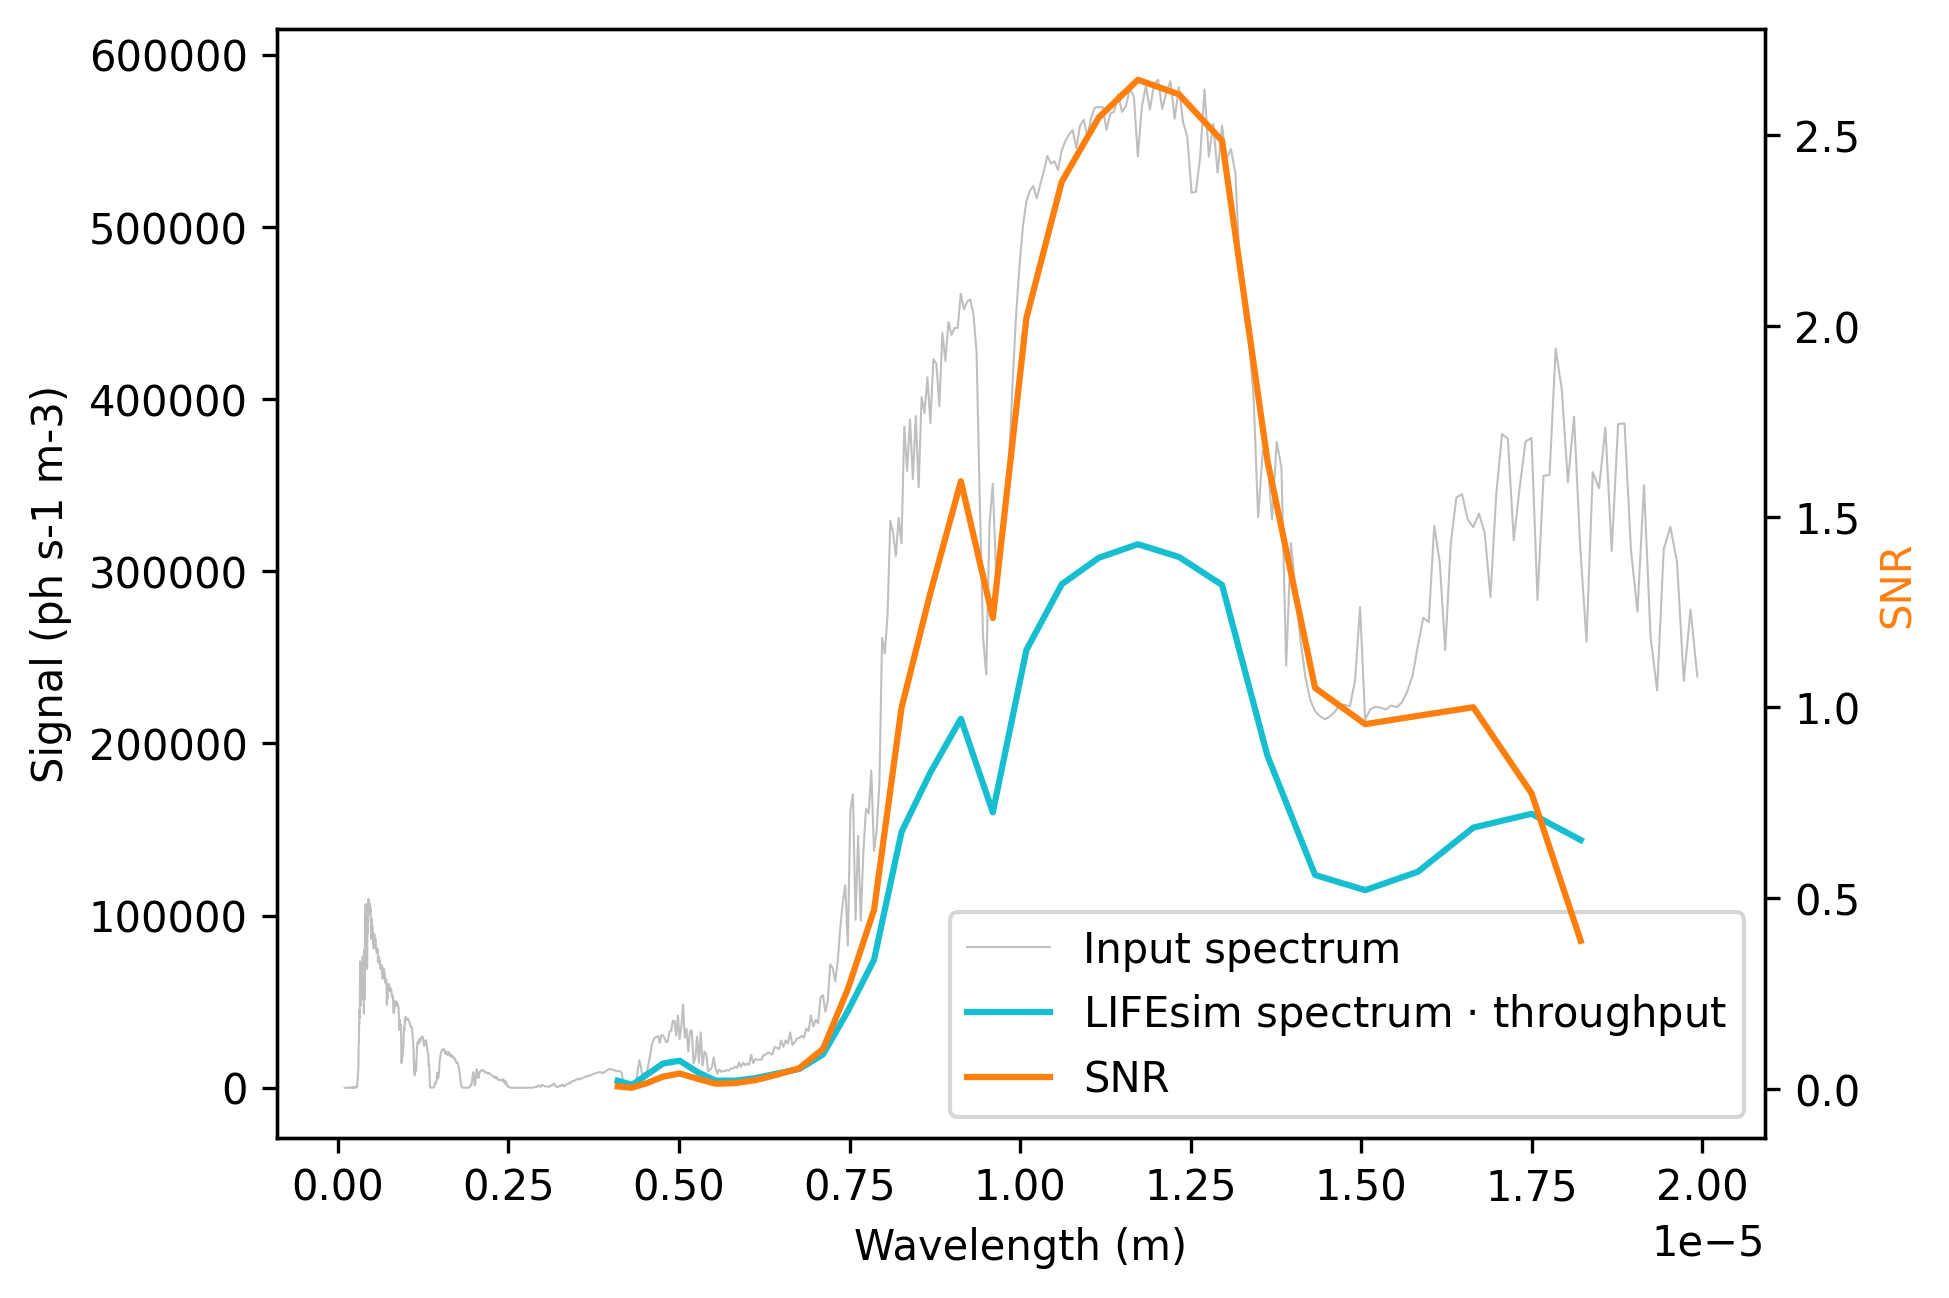

In [13]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')
ln2 = plt.plot(spectrum[0], flux_planet / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')
ax2=ax.twinx()
ln3 = ax2.plot(spectrum[0], spectrum[1],c='tab:orange', label='SNR')

lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-3)')
ax2.set_ylabel("SNR",c='tab:orange')
plt.show()

#### test safe mode off

In [14]:
# test safe mode off

spectrum_tmo, flux_planet_tmo, noise_tmo = instrument.get_spectrum(temp_s=5778,  # star temperature in K
                                                       radius_s=1,  # star radius in solar radii
                                                       distance_s=10,  # distance to system in pc
                                                       lat_s=0.78,  # ecliptic latitude of observation in rad
                                                       z=3,  # zodi level
                                                       angsep=0.1,  # angular separation of planet in arcsec
                                                       flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                       safe_mode=True,
                                                      integration_time=integration_time)

In [19]:
noise_tmo[3]

array([4.52049504e-24, 5.16158313e-22, 4.64334386e-20, 3.32951464e-18,
       1.92414567e-16, 9.05674819e-15, 3.50696487e-13, 1.12784830e-11,
       3.03993130e-10, 6.92647732e-09, 1.34510403e-07, 2.24377737e-06,
       3.23895233e-05, 4.07468130e-04, 4.49739519e-03, 4.38307423e-02,
       3.79476039e-01, 2.93553960e+00, 2.04024133e+01, 1.28070980e+02,
       7.29783350e+02, 3.79364717e+03, 1.80799336e+04, 7.94145153e+04,
       3.23435873e+05, 1.23070866e+06, 4.42018649e+06, 1.51958834e+07,
       5.09144975e+07, 1.69566014e+08, 2.81083253e+08])

In [16]:
noise_tmo
noise_photon = noise_tmo[1][0] + noise_tmo[1][1] + noise_tmo[2][0]
noise_planet = noise_tmo[0] - noise_photon

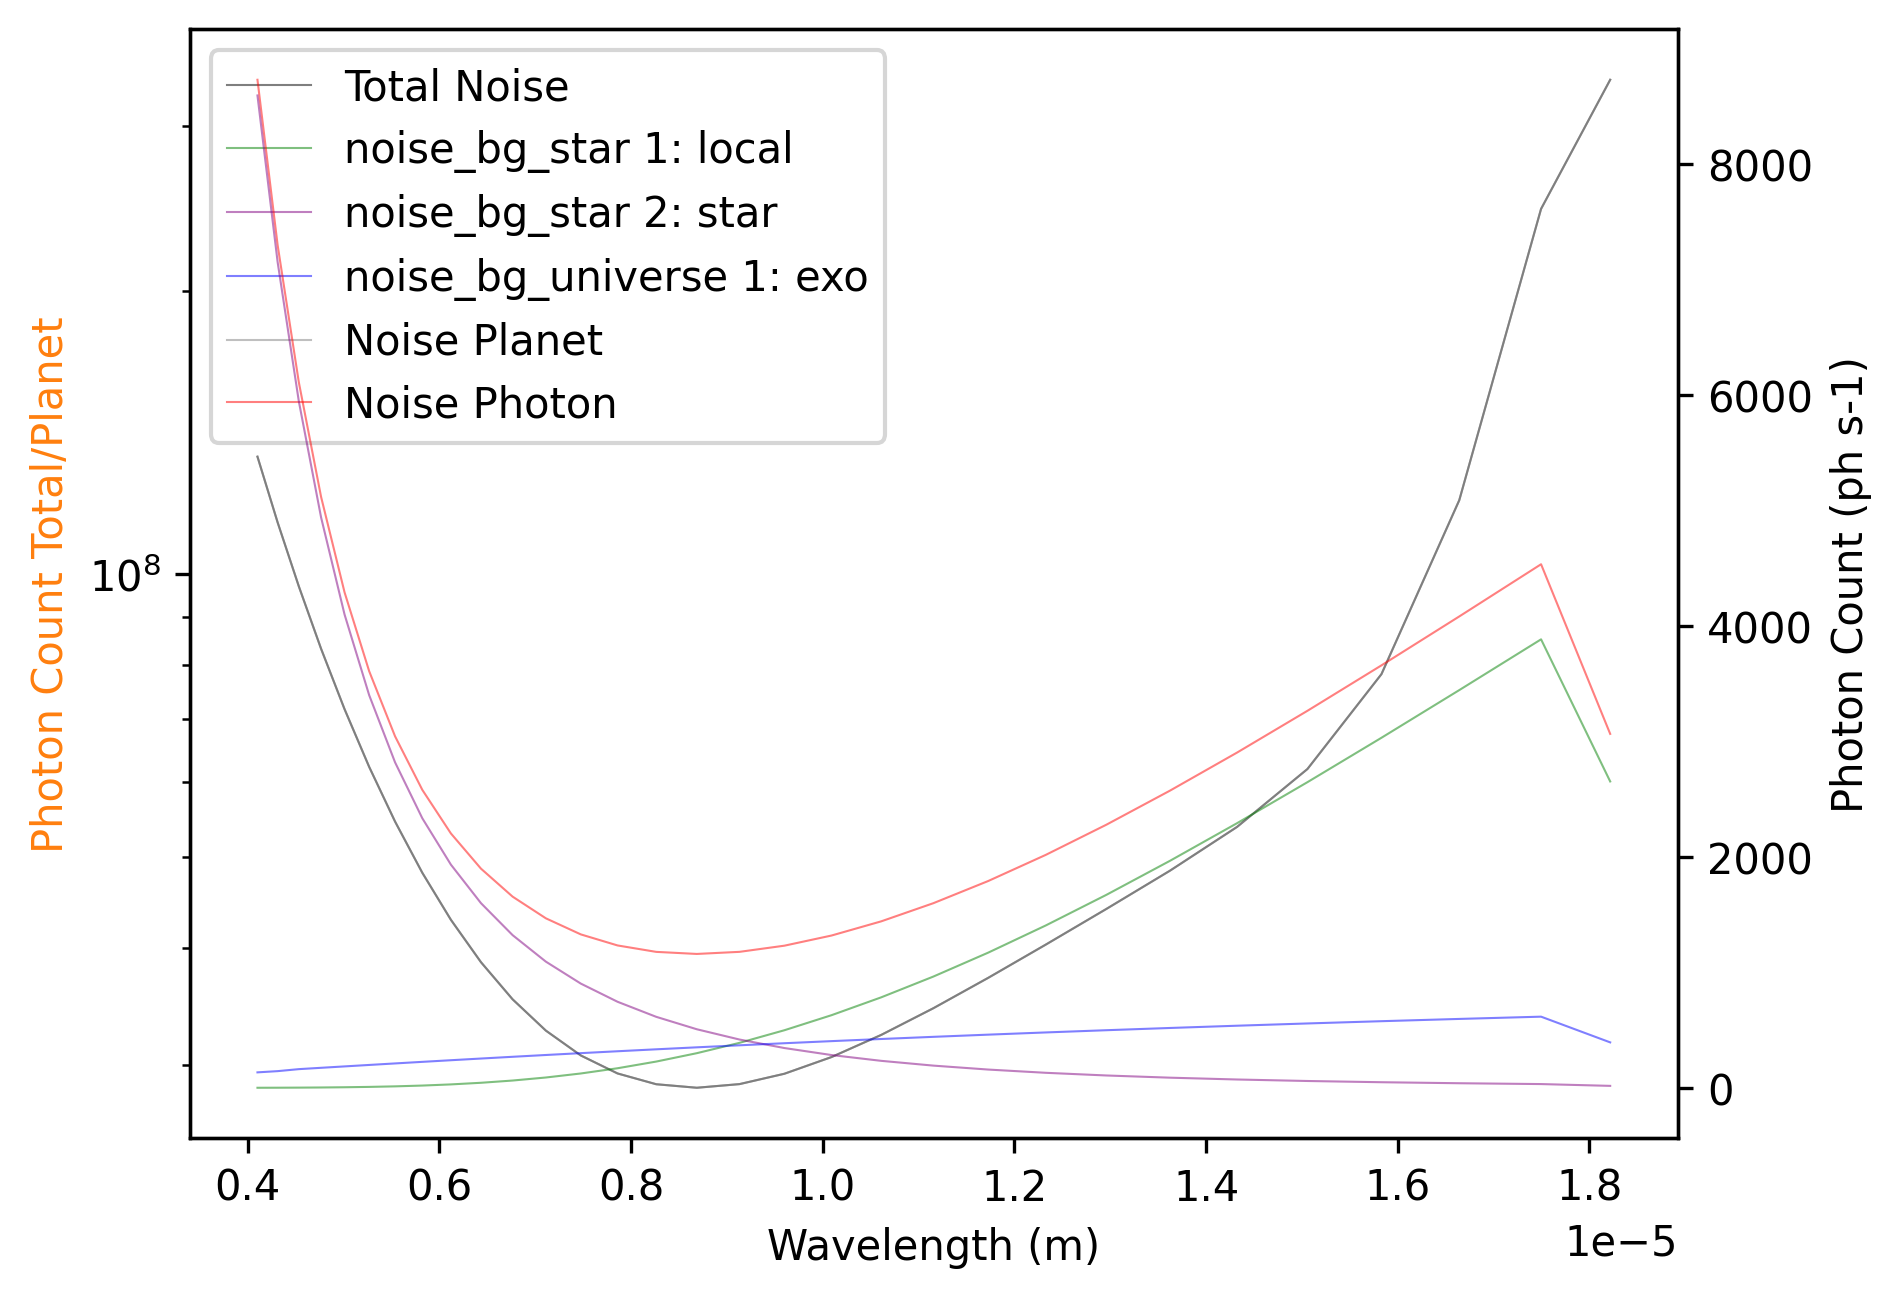

In [17]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', alpha=0.5, label='Total Noise')
lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', alpha=0.5, label='Noise Planet')
ax2=ax.twinx()
lnphoton = plt.plot(spectrum_tmo[0], noise_photon, lw=0.5, c='red', alpha=0.5, label='Noise Photon')
ln2 = ax2.plot(spectrum_tmo[0], noise_tmo[1][0], lw=0.5, c='green', alpha=0.5, label='noise_bg_star 1: local')
ln3 = ax2.plot(spectrum_tmo[0], noise_tmo[1][1], lw=0.5, c='purple', alpha=0.5, label='noise_bg_star 2: star')
ln4 = ax2.plot(spectrum_tmo[0], noise_tmo[2][0], lw=0.5, c='blue', alpha=0.5, label='noise_bg_universe 1: exo')
# ln2 = plt.plot(spectrum[0], flux_planet / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')
# ax2=ax.twinx()
# ln3 = ax2.plot(spectrum[0], spectrum[1],c='tab:orange', label='SNR')
# ln5 = ax2.plot(spectrum_tmo[0], noise_tmo[3][0], lw=0.5, c='orange', alpha=0.5, label='noise_inst 1: mirror')

lns = ln1 + ln2 + ln3 + ln4 + lnplanet + lnphoton # + ln5
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper left')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax2.set_ylabel('Photon Count (ph s-1)')
ax.set_ylabel("Photon Count Total/Planet",c='tab:orange')
plt.show()

ValueError: x and y must have same first dimension, but have shapes (31,) and (1,)

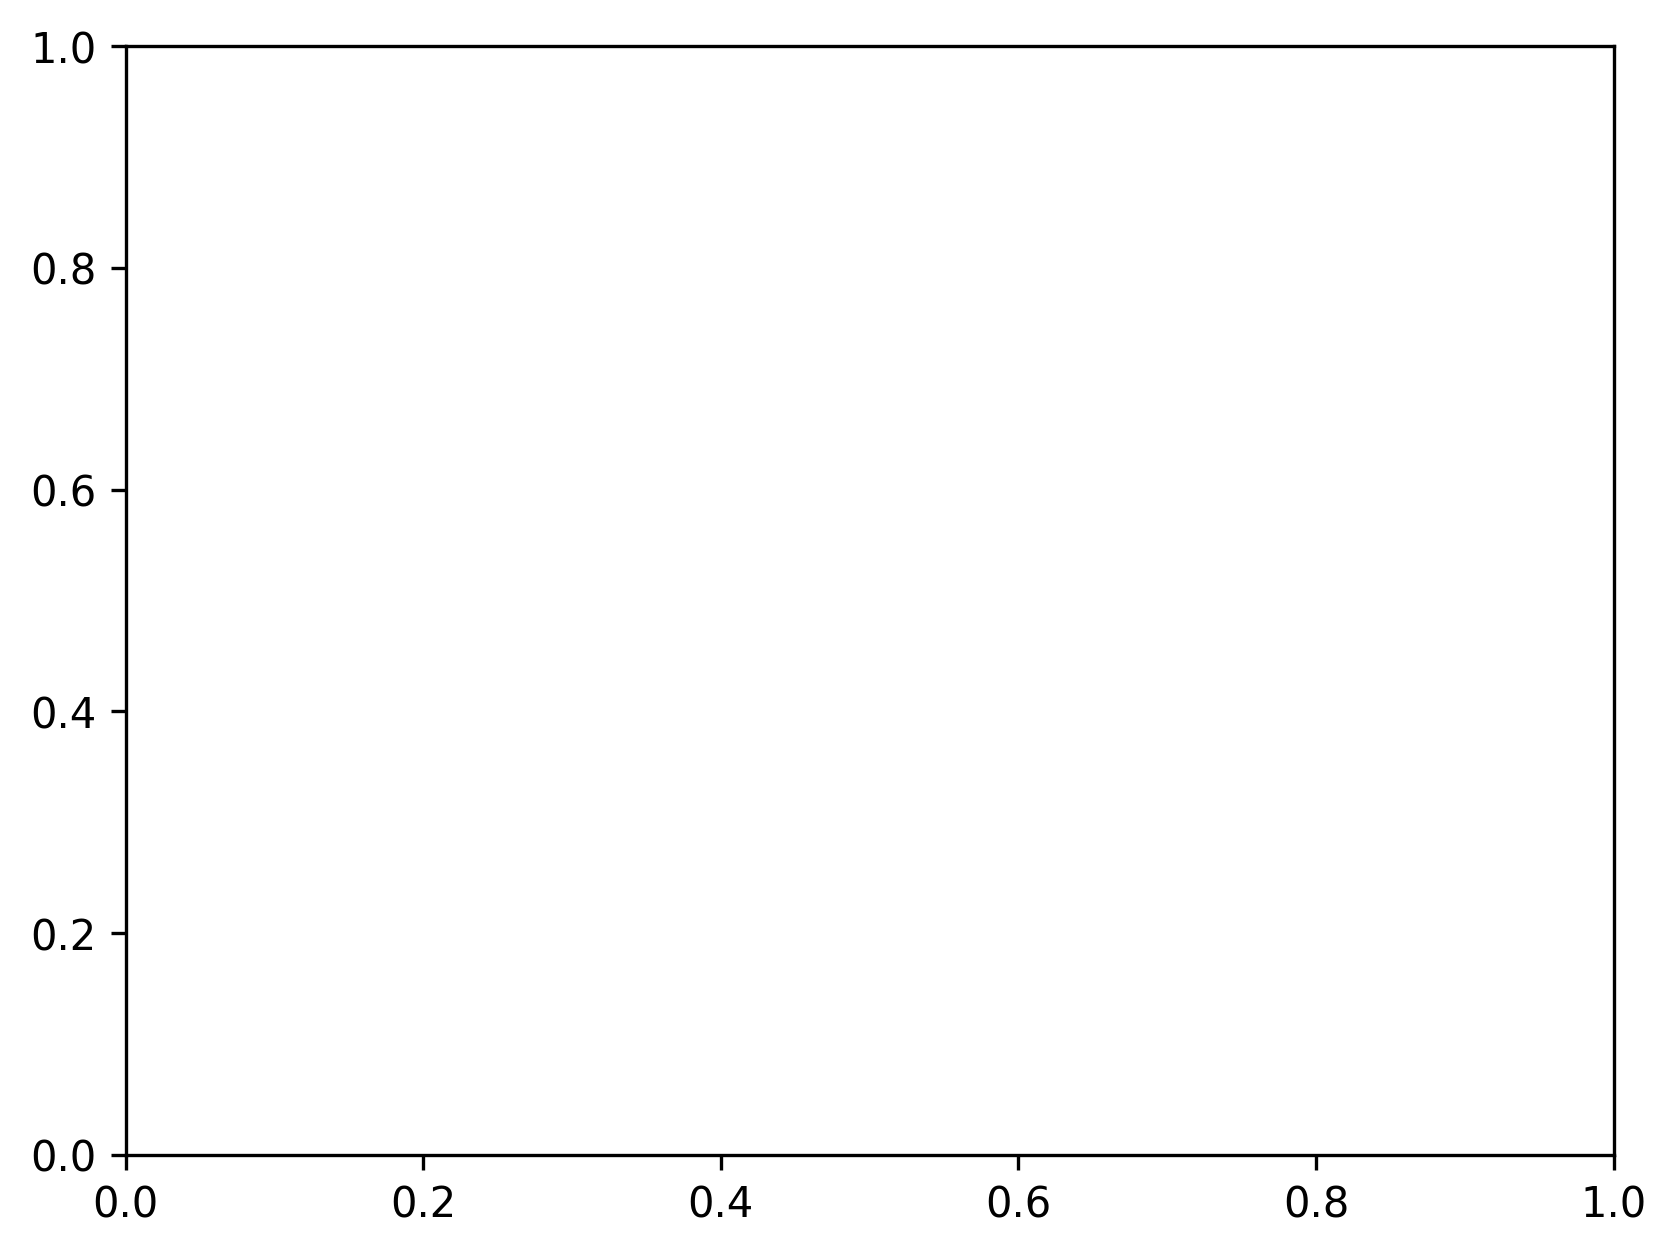

In [18]:
# only thermal noise and local zodi
fig, ax = plt.subplots(dpi=300)

ln1 = ax.plot(spectrum_tmo[0], noise_tmo[3][0], lw=0.5, c='red', alpha=0.5, label='noise_inst 1: mirror')
# ln2 = ax.plot(spectrum_tmo[0], noise_tmo[3][1], lw=0.5, c='blue', alpha=0.5, label='noise_inst 2: detector')
ln3 = ax.plot(spectrum_tmo[0], noise_tmo[1][0], lw=0.5, c='green', alpha=0.5, label='noise_bg_star 1: local')

ax2=ax.twinx()
# ln4 = ax.plot(spectrum_tmo[0], noise_tmo[4]/0.7, lw=0.5, c='purple', alpha=0.5, label='noise_inst 2: dark current')  

lns = ln1 + ln2 + ln3 + ln4 # + ln4 + lnphoton + lnplanet + ln5
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Photon Count (ph s-1)')
# ax2.set_ylabel("electron count",c='tab:orange')
plt.show()

### Actual spectrum as seen by LIFE

In [66]:
flux_actual = flux_planet + np.random.normal(loc=0, scale=flux_planet/spectrum[1])

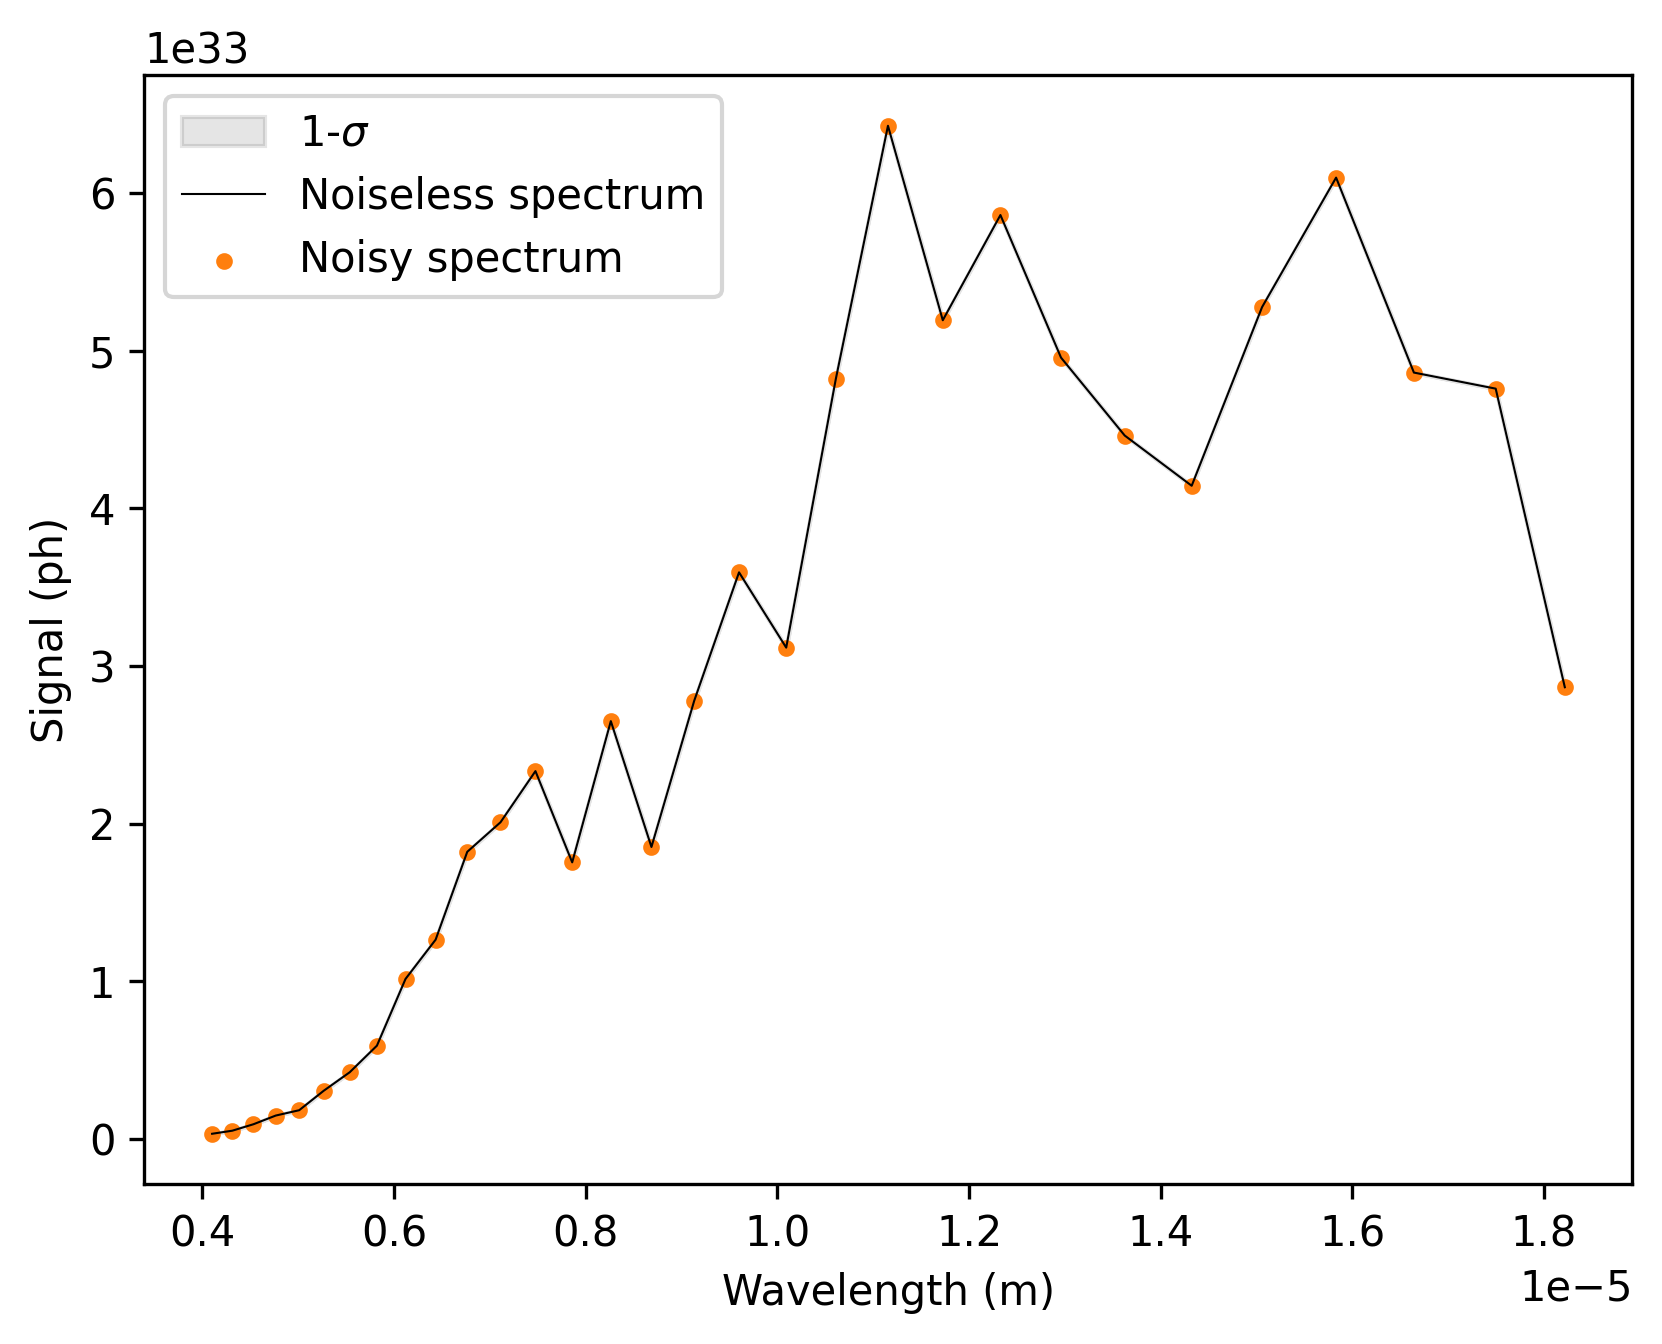

In [67]:
fig, ax = plt.subplots(dpi=300)

plt.fill_between(spectrum[0], 
                 flux_planet-flux_planet/spectrum[1], 
                 flux_planet+flux_planet/spectrum[1],
                color='k',
                alpha=0.1, label='1-$\sigma$')
plt.plot(spectrum[0], flux_planet, c='k', lw=0.5, label='Noiseless spectrum')
plt.scatter(spectrum[0], flux_actual, c='tab:orange', marker='.', label='Noisy spectrum')

plt.legend()
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph)')

plt.show()

### Get wavelength dependent throughput

In [68]:
transm_eff, transm_noise = instrument.run_socket(s_name='transmission',
                                                   method='transmission_efficiency',
                                                   index=None)

In [69]:
throughput = bus.data.inst['eff_tot'] * transm_eff

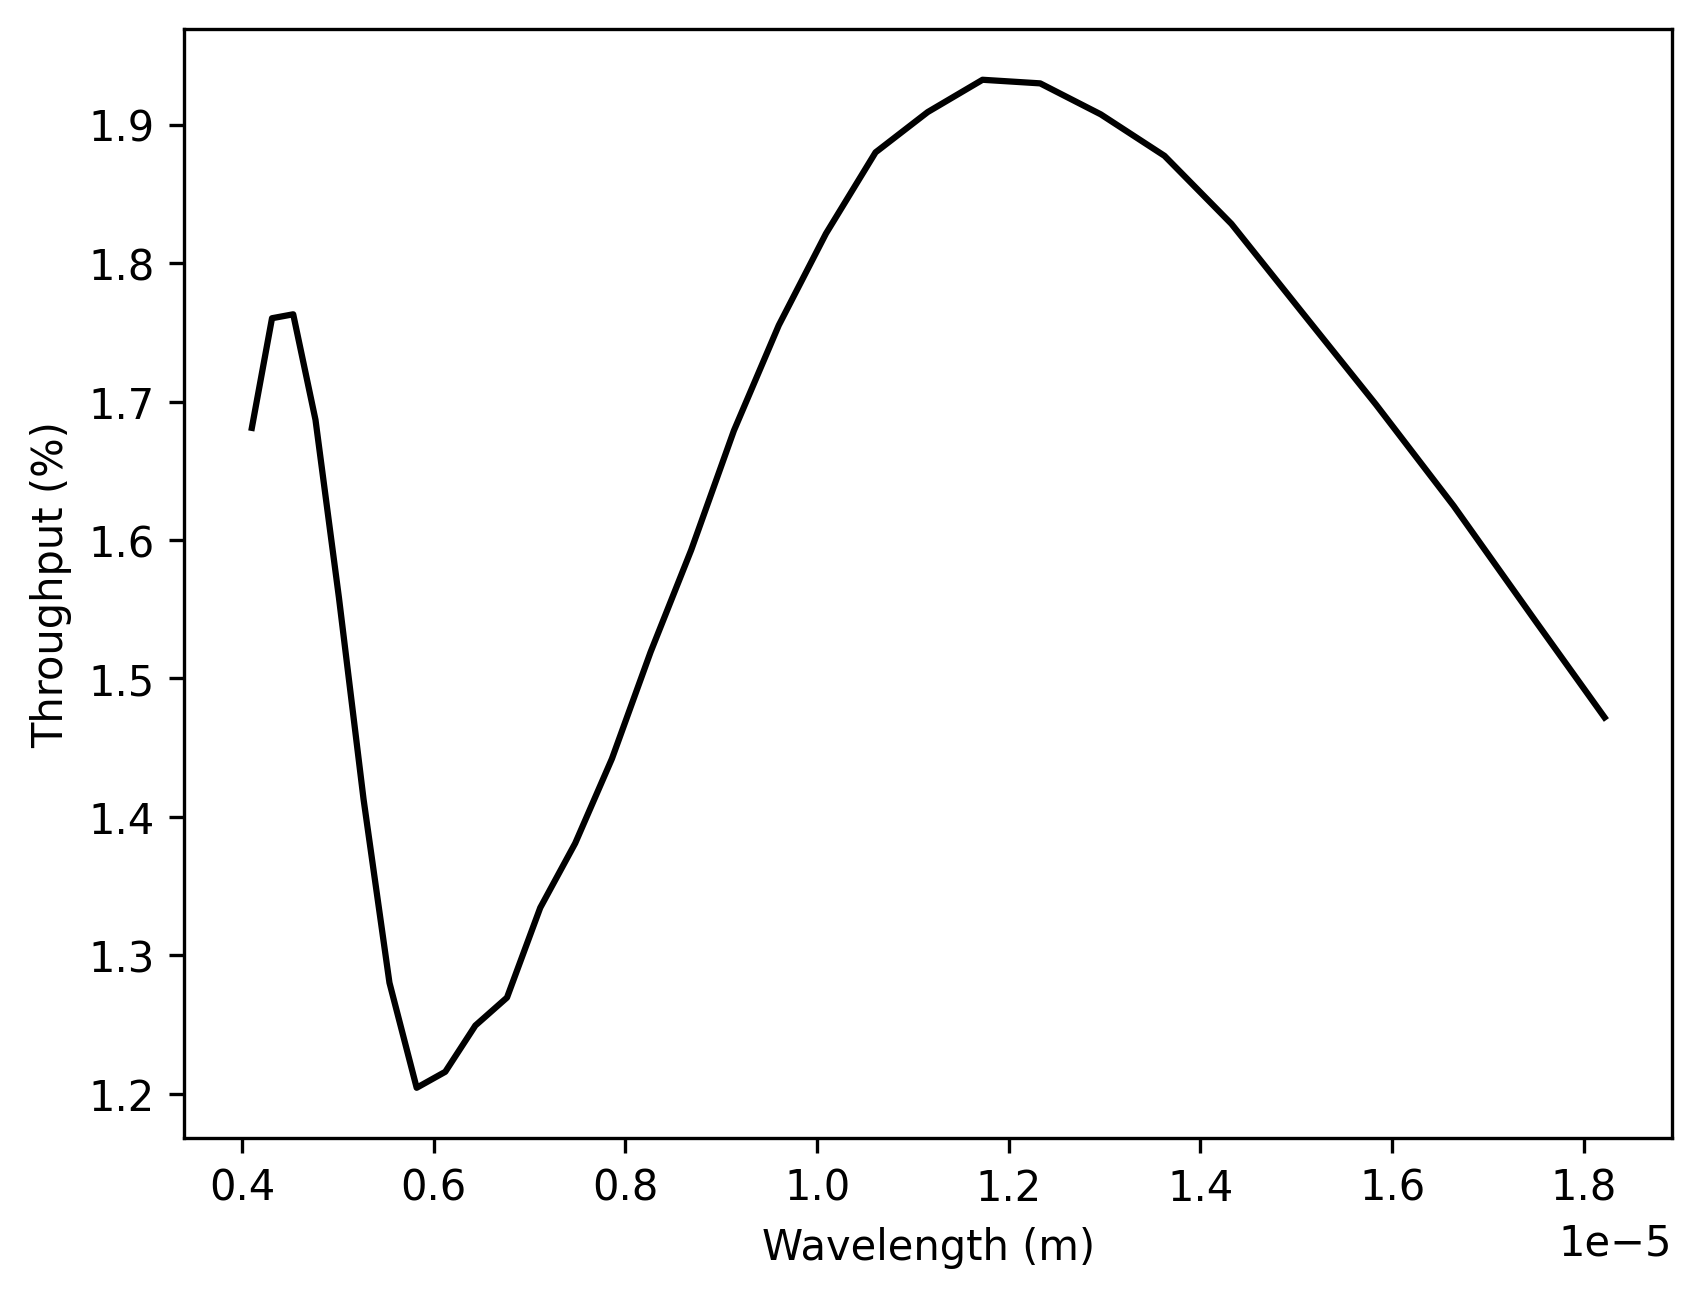

In [70]:
fig, ax = plt.subplots(dpi=300)
plt.plot(spectrum[0], throughput*100, c='k')
plt.xlabel('Wavelength (m)')
plt.ylabel('Throughput (%)')
plt.show()

### Scale up spectrum by theoretical

In [71]:
pf_act = prefactor * transm_eff
flux_scaled = flux_actual / throughput

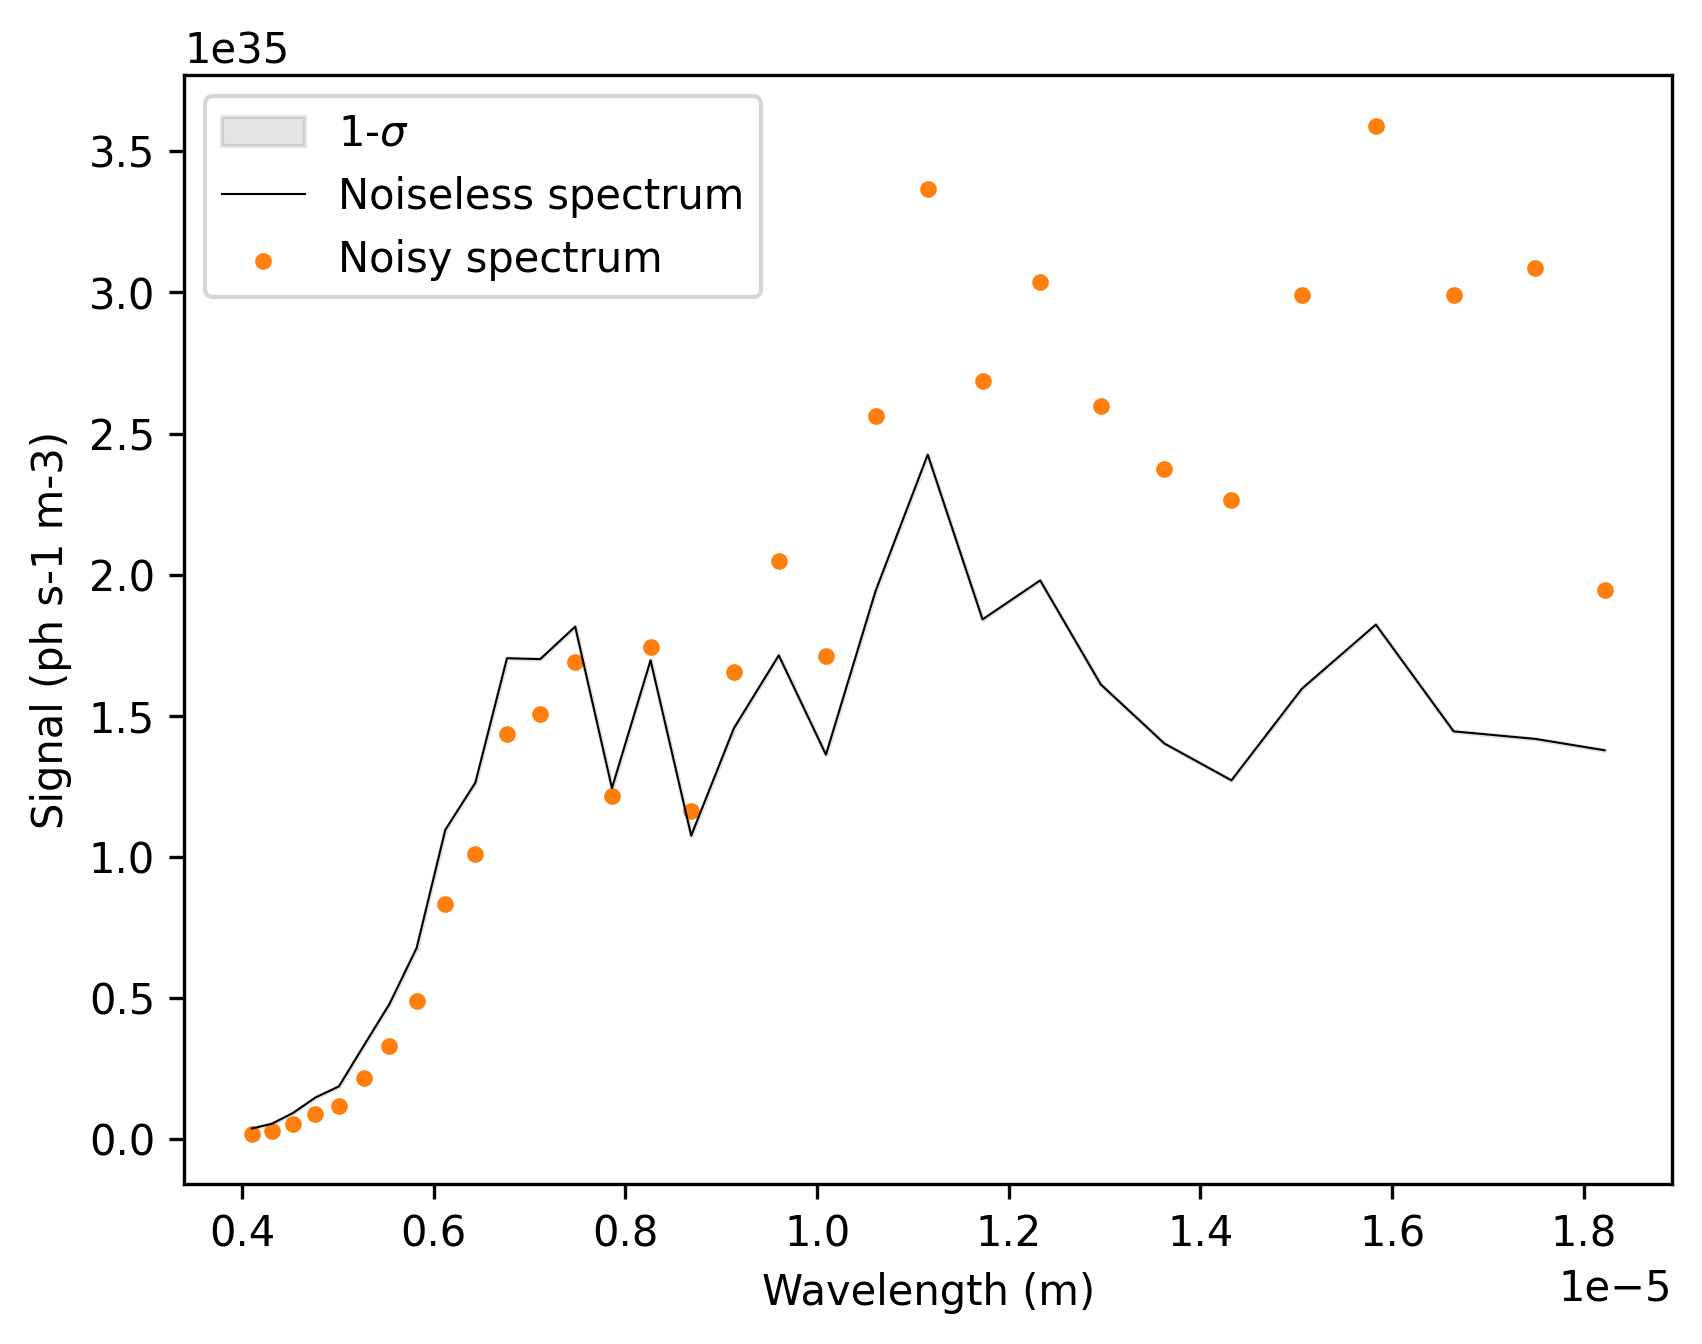

In [72]:
fig, ax = plt.subplots(dpi=300)

plt.fill_between(spectrum[0], 
                 (flux_planet-flux_planet/spectrum[1])/pf_act, 
                 (flux_planet+flux_planet/spectrum[1])/pf_act,
                color='k',
                alpha=0.1, label='1-$\sigma$')
plt.plot(spectrum[0], flux_planet/pf_act, c='k', lw=0.5, label='Noiseless spectrum')
plt.scatter(spectrum[0], flux_scaled, c='tab:orange', marker='.', label='Noisy spectrum')

plt.legend()
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-3)')

plt.show()

### Comparison to just using the theoretical

In [73]:
# bin theoretical spectrum
f_theo = spectres(new_wavs=bus.data.inst['wl_bin_edges'],
                  spec_wavs=lam_lifesim.value,
                  spec_fluxes=f_lifesim.value,
                  edge_mode=True)

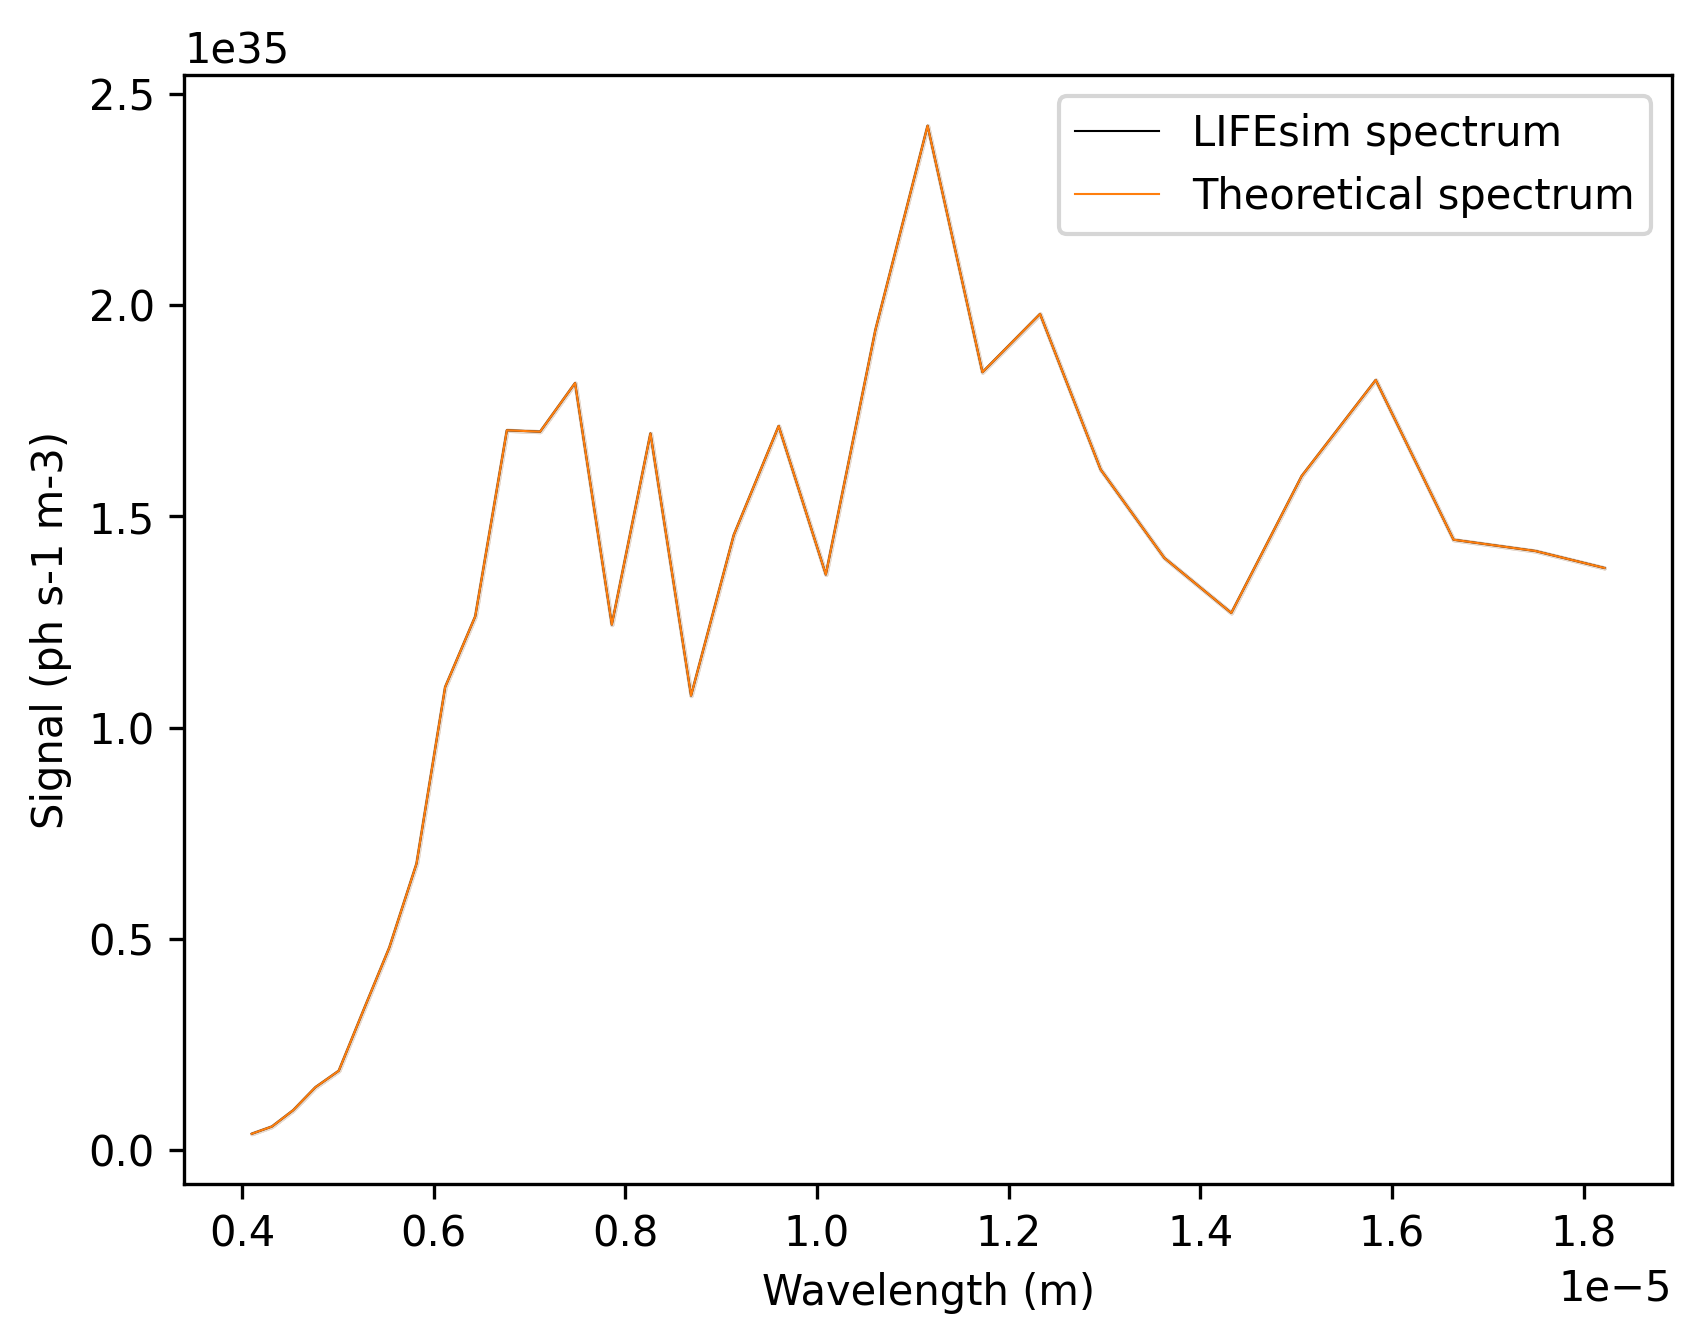

In [74]:
fig, ax = plt.subplots(dpi=300)

plt.fill_between(spectrum[0], 
                 (flux_planet-flux_planet/spectrum[1])/pf_act, 
                 (flux_planet+flux_planet/spectrum[1])/pf_act,
                color='k',
                alpha=0.1)
plt.plot(spectrum[0], flux_planet/pf_act, c='k', lw=0.5, label='LIFEsim spectrum')

plt.fill_between(spectrum[0], 
                 f_theo-f_theo/spectrum[1], 
                 f_theo+f_theo/spectrum[1],
                color='tab:orange',
                alpha=0.1)
plt.plot(spectrum[0], f_theo, c='tab:orange', lw=0.5, label='Theoretical spectrum')



plt.legend()
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-3)')

plt.show()